# Physical Experiment 1: Single BVD beam with constanct resistance

## Do not run: outdated methods

For this physical experiment, we will try to succesfully determine the resistance of a single BVD beam, using a myDAQ frequency sweep.

First, we import our tools:

In [130]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager import Bridge
from myDAQ_manager import logs_to_U

import numpy as np
import matplotlib.pyplot as plt

Next, we initialize the beam library, reference resistance and inlet voltage:

In [ ]:
# Initiation: load beam library, select beams for experiment and set parameters.
library_name = 'BVD4single'
library = open_beam_library(library_name + '.json')
selection = ['A1','D1']
lib = sublibrary(selection, library)

R_ref = 10 # Ohm
R_int = None # Ohm
U_in = 1 #

Let's have a quick look at the impedance response of the chosen beam:

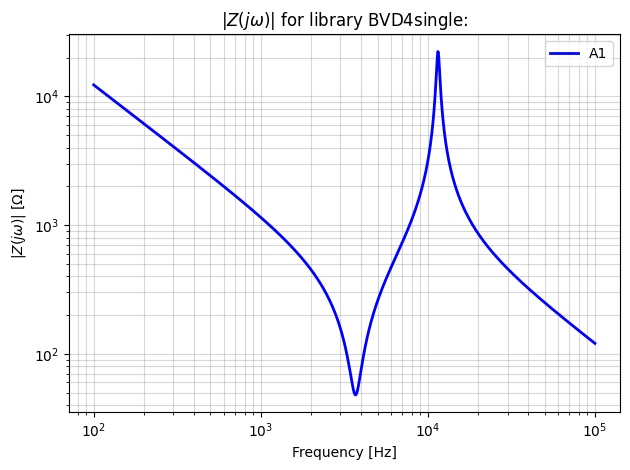

In [132]:
f_arr_plot = np.logspace(2, 5, 1000)
w_arr_plot = 2*np.pi*f_arr_plot
colors = ['blue']

fig, ax = plt.subplots()

for key, color in zip(list(lib.keys()), colors):
    
    y = lib[key].admittance(w_arr_plot)
    z_abs = 1 / np.abs(y)

    ax.loglog(f_arr_plot, z_abs, color=color, label=key, linewidth=2)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()

Let's perform our experiment. As for beam A1, a resistor of 470 Ohm was selected (which was given as R0 in library BVD4). We add the topology, initialize the bridge object and run the resistance predictor.

[33.18415042 44.82297795]


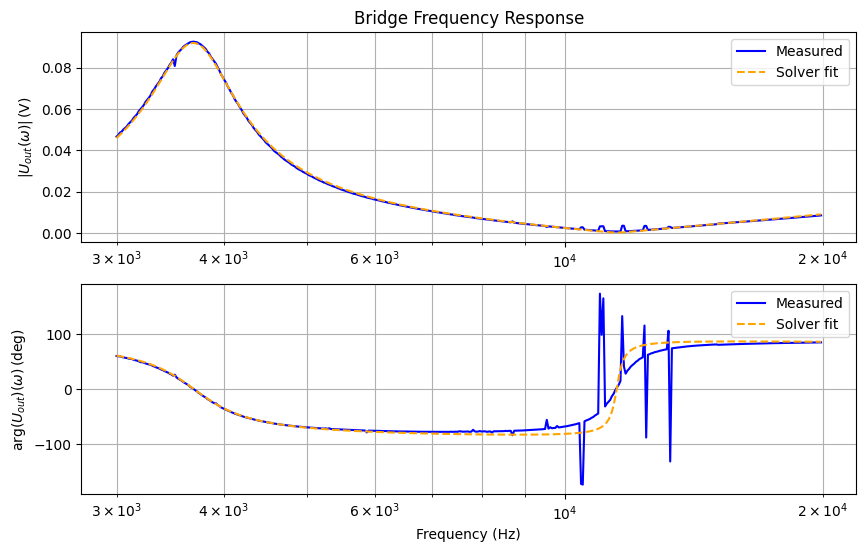

In [133]:
topology = [(0, 1), (1,2)]
struc = Bridge()
struc.construct(lib, topology)

# The measured response:
filename = 'vergelijkbeste47.1.txt'
w_arr, U_out_mes = logs_to_U(filename, U_in)
f_arr = w_arr / (2*np.pi)

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(w_arr, U_in, U_out_mes, R_ref)
print(R_pred)

# Plotting:
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_arr_pred = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_pred)
U_out_pred = U_arr_pred[-1,:]
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()


In [134]:
R_deformed = [48] # 50 Ohm R_0 for all beams in BVD1.json

# The measured response (with noise!) should equal:
U_arr_theory = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_deformed, R_int = R_int, add_noise = False, sigma=None, rng=None)
U_out_theory = U_arr_theory[-1,:]
U_out_mag_theory = np.abs(U_out_theory)
U_out_phase_theory = np.angle(U_out_theory)

plt.figure(figsize=(10, 12))

# Plot Magnitude
plt.subplot(4, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_theory, color='orange', linestyle='--', label = f'Theory')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
# plt.ylim(0.1,0.2)
# plt.xlim(3.5e3, 4e3)
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(4, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_theory), color='orange', linestyle='--', label = f'Theory')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()
# plt.ylim(-1.1,1.1)
# plt.xlim(3.69e3, 3.72e3)

plt.subplot(4, 1, 3)
plt.semilogx(f_arr, 20*np.log10(U_out_mag_mes/U_in), color='blue', label = 'Measured')
plt.semilogx(f_arr, 20*np.log10(U_out_mag_theory/U_in), color='orange', linestyle='--', label = f'Theory')
plt.ylabel('Gain (dB)')
plt.grid(True, which="both")
plt.legend(loc = 'lower right')
plt.title('Bridge Frequency Response')
# plt.ylim(-22, -20)
# plt.xlim(1e3, 1.2e3)
# Plot Phase:
plt.subplot(4, 1, 4)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_theory), color='orange', linestyle='--', label = f'Theory')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

IndexError: list index out of range

38.7 wordt gezien als: 41.11

43.4 wordt gezien als: 44.64    

47.8 wordt gezien als: 48.82 

84.7 wordt gezien als 77.7

138.7 wordt gezien als 118.36 

258.7 wordt gezien als 211.7










Polynoom:
 
0.7739 x + 11.45


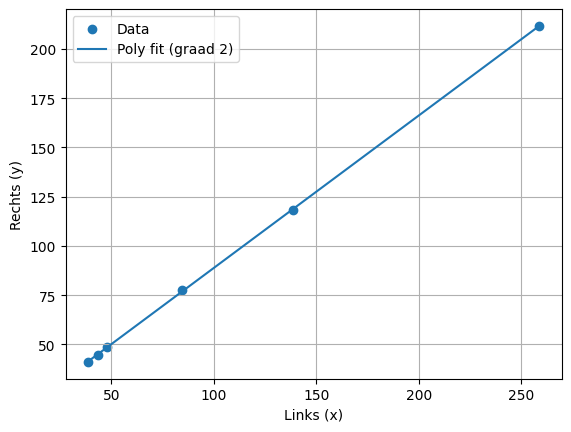

In [ ]:
x = [38.7, 43.4, 47.8, 84.7, 138.7, 258.7]      # links (x-as)
y = [41.11, 44.64, 48.82, 77.7, 118.36, 211.7]  # rechts (y-as)

# Plot
coeffs = np.polyfit(x, y, 1)
poly = np.poly1d(coeffs)

print("Polynoom:")
print(poly)

# Mooie lijn maken
x_fit = np.linspace(min(x), max(x), 200)
y_fit = poly(x_fit)

# Plot
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="Poly fit (graad 2)")

plt.xlabel("Links (x)")
plt.ylabel("Rechts (y)")
plt.legend()
plt.grid(True)
plt.show()

y = 0.8x+5

pred: 258.7 --> 181

Met Rref=10


0 ohm --> 52.94142871

4.7ohm --> 57.56586892

10ohm --> 62.63279126

47 ohm --> 99.50136987

100 ohm --> 150.90317182

220 ohm --> 266.32190311




Polynoom:
 
0.9686 x + 16.18


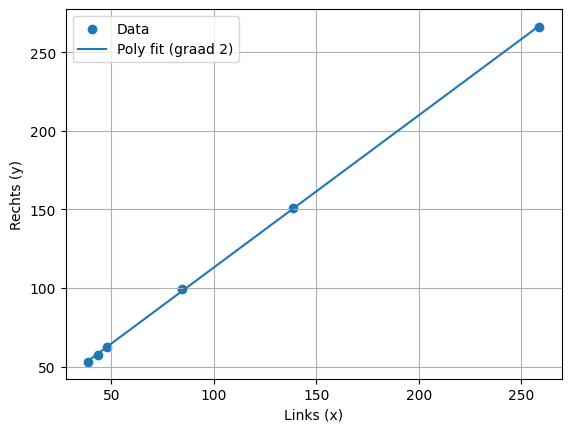

In [ ]:
x_ohm = np.array([0, 4.7, 10, 47, 100, 220])
y = np.array([52.94142871, 57.56586892, 62.63279126, 
              99.50136987, 150.90317182, 266.32190311])

# 38.7 ohm toevoegen
x_new = x_ohm + 38.7

coeffs = np.polyfit(x, y, 1)
poly = np.poly1d(coeffs)

print("Polynoom:")
print(poly)

# Mooie lijn maken
x_fit = np.linspace(min(x), max(x), 200)
y_fit = poly(x_fit)

# Plot
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="Poly fit (graad 2)")

plt.xlabel("Links (x)")
plt.ylabel("Rechts (y)")
plt.legend()
plt.grid(True)
plt.show()